In [3]:
import pandas as pd
import os.path
import pickle
import numpy as np
from tensorflow import keras
from tensorflow.keras import utils

In [1]:
import pandas as pd

In [2]:
d=pd.read_csv(r"C:\Users\HP\Downloads\train.tsv", sep='\t')
d

,Unnamed: 0,title,text,subject,date,label
0,2619,Ex-CIA head says Trump remarks on Russia inter...,Former CIA director John Brennan on Friday cri...,politicsNews,"July 22, 2017",1
1,16043,YOU WON’T BELIEVE HIS PUNISHMENT! HISPANIC STO...,How did this man come to OWN this store? There...,Government News,"Jun 19, 2017",0
2,876,Federal Reserve governor Powell's policy views...,President Donald Trump on Thursday tapped Fede...,politicsNews,"November 2, 2017",1
3,19963,SCOUNDREL HILLARY SUPPORTER STARTS “TrumpLeaks...,Hillary Clinton ally David Brock is offering t...,left-news,"Sep 17, 2016",0
4,10783,NANCY PELOSI ARROGANTLY DISMISSES Questions on...,Pleading ignorance is a perfect ploy for Nancy...,politics,"May 26, 2017",0
...,...,...,...,...,...,...
29995,6880,U.S. aerospace industry urges Trump to help Ex...,The chief executive of the U.S. Aerospace Indu...,politicsNews,"December 6, 2016",1
29996,17818,Highlights: Hong Kong leader Carrie Lam delive...,The following are highlights of the maiden pol...,worldnews,"October 11, 2017",1
29997,5689,Obama Literally LAUGHS At Claims That Brexit M...,If there s one thing President Barack Obama is...,News,"June 28, 2016",0
29998,15805,Syrian army takes full control of Deir al-Zor ...,The Syrian army and its allies have taken full...,worldnews,"November 2, 2017",1


In [3]:
label_counts = d['label'].value_counts()

print(label_counts)

label
0    15478
1    14522
Name: count, dtype: int64


In [5]:
import time
from keras.callbacks import TensorBoard, CSVLogger
from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense,Flatten,LSTM,Conv1D,GlobalMaxPool1D,Dropout,Bidirectional
from keras.layers import Embedding
from keras import optimizers
from keras.layers import Input
from keras.models import Model
from tensorflow.keras.utils import plot_model
from IPython.display import SVG
from nltk.corpus import stopwords

In [6]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [7]:
!pip install pydot==1.2.3

In [12]:
print( d.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  30000 non-null  int64 
 1   title       30000 non-null  object
 2   text        30000 non-null  object
 3   subject     30000 non-null  object
 4   date        30000 non-null  object
 5   label       30000 non-null  int64 
dtypes: int64(2), object(4)
memory usage: 1.4+ MB
None


In [8]:
train_data = d.drop(d.columns[0], axis=1)

In [9]:
train_data

,title,text,subject,date,label
0,Ex-CIA head says Trump remarks on Russia inter...,Former CIA director John Brennan on Friday cri...,politicsNews,"July 22, 2017",1
1,YOU WON’T BELIEVE HIS PUNISHMENT! HISPANIC STO...,How did this man come to OWN this store? There...,Government News,"Jun 19, 2017",0
2,Federal Reserve governor Powell's policy views...,President Donald Trump on Thursday tapped Fede...,politicsNews,"November 2, 2017",1
3,SCOUNDREL HILLARY SUPPORTER STARTS “TrumpLeaks...,Hillary Clinton ally David Brock is offering t...,left-news,"Sep 17, 2016",0
4,NANCY PELOSI ARROGANTLY DISMISSES Questions on...,Pleading ignorance is a perfect ploy for Nancy...,politics,"May 26, 2017",0
...,...,...,...,...,...
29995,U.S. aerospace industry urges Trump to help Ex...,The chief executive of the U.S. Aerospace Indu...,politicsNews,"December 6, 2016",1
29996,Highlights: Hong Kong leader Carrie Lam delive...,The following are highlights of the maiden pol...,worldnews,"October 11, 2017",1
29997,Obama Literally LAUGHS At Claims That Brexit M...,If there s one thing President Barack Obama is...,News,"June 28, 2016",0
29998,Syrian army takes full control of Deir al-Zor ...,The Syrian army and its allies have taken full...,worldnews,"November 2, 2017",1


In [10]:
train_data.duplicated().sum()

92

In [11]:
train_data.drop_duplicates(inplace=True)

In [12]:
train_data.duplicated().sum()

0

data preprocessing


In [13]:
pip install textblob scikit-learn pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [14]:
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

def get_sentiment_features(text):
    """
    Extract sentiment features from text using TextBlob.
    Returns polarity and subjectivity scores.
    """
    try:
        blob = TextBlob(str(text))
        return pd.Series({
            'polarity': blob.sentiment.polarity,
            'subjectivity': blob.sentiment.subjectivity,
        })
    except:
        return pd.Series({
            'polarity': 0.0,
            'subjectivity': 0.0,
        })

def create_feature_matrix(train_data):
    """
    Create a feature matrix combining TF-IDF and sentiment features.

    Parameters:
    train_data (pd.DataFrame): DataFrame containing 'title', 'text', and 'processed_text' columns

    Returns:
    tuple: (X, y) where X is the feature matrix and y is the labels
    """
    print("Extracting sentiment features...")
    # Extract sentiment features from title and text
    title_sentiments = train_data['title'].apply(get_sentiment_features)
    text_sentiments = train_data['text'].apply(get_sentiment_features)

    # Rename columns
    title_sentiments.columns = ['title_polarity', 'title_subjectivity']
    text_sentiments.columns = ['text_polarity', 'text_subjectivity']

    # Add sentiment features to main dataframe
    train_data = pd.concat([train_data, title_sentiments, text_sentiments], axis=1)

    print("Creating TF-IDF features...")
    # Create TF-IDF features
    tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
    text_features = tfidf.fit_transform(train_data['processed_text'])

    print("Combining features...")
    # Convert sparse matrix to dense array
    text_features_dense = text_features.toarray()

    # Create feature matrix
    X = np.hstack((
        text_features_dense,
        train_data[['title_polarity', 'title_subjectivity',
                   'text_polarity', 'text_subjectivity']].values
    ))

    # Get labels
    y = train_data['label']

    print(f"Final feature matrix shape: {X.shape}")
    return X, y, tfidf

# Example usage
if __name__ == "__main__":
    # Assuming train_data is your DataFrame
    # X, y, tfidf_vectorizer = create_feature_matrix(train_data)
    pass

In [15]:
import nltk
nltk.download('all')  # This will download all NLTK resources

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]    |

True

feature engineering

In [16]:
# 1. Required Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from textblob import TextBlob
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# 2. Load and Initial Setup
# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')



# 3. Text Preprocessing Function
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]

    # Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]

    return ' '.join(tokens)

# 4. Apply preprocessing to title and text columns
train_data['processed_title'] = train_data['title'].apply(preprocess_text)
train_data['processed_text'] = train_data['text'].apply(preprocess_text)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [18]:
df=pd.read_csv(r"C:\Users\HP\Downloads\test.tsv", sep='\t')
df

,Unnamed: 0,title,text,subject,date,label
0,8104,Conservatives Will HATE What Donald Trump Just...,Donald Trump isn t exactly a stranger to makin...,News,"February 14, 2016",0
1,7467,Trump victory may create new tension between U...,Donald Trump’s U.S. election victory may creat...,politicsNews,"November 9, 2016",1
2,9473,WATCH: Hundreds of ILLEGAL ALIENS Storm Senate...,A couple of quick questions come to mind when ...,politics,"Nov 9, 2017",0
3,276,"Democratic Senator Franken to resign: CNN, cit...",U.S. Democratic Senator Al Franken will announ...,politicsNews,"December 7, 2017",1
4,19274,GANG OF DOMESTIC TERRORISTS Violently Attack L...,***WARNING*** Violence is graphic***This Trump...,left-news,"Jan 21, 2017",0
...,...,...,...,...,...,...
8262,5469,Russian MP says Flynn was forced to resign to ...,A senior Russian lawmaker said on Tuesday it w...,politicsNews,"February 14, 2017",1
8263,5079,Highlights: The Trump presidency on March 7 at...,Highlights of the day for U.S. President Donal...,politicsNews,"March 7, 2017",1
8264,20425,SHOCKER! WAS MUSLIM TERRORIST GAY? Used Gay Da...,"Of course, Mateen s Muslim father vehemently d...",left-news,"Jun 13, 2016",0
8265,22063,John McCain and The Cancer of Conflict,Patrick Henningsen 21st Century WireThis week ...,US_News,"July 21, 2017",0


In [19]:
test_data = df.drop(df.columns[0], axis=1)
test_data

,title,text,subject,date,label
0,Conservatives Will HATE What Donald Trump Just...,Donald Trump isn t exactly a stranger to makin...,News,"February 14, 2016",0
1,Trump victory may create new tension between U...,Donald Trump’s U.S. election victory may creat...,politicsNews,"November 9, 2016",1
2,WATCH: Hundreds of ILLEGAL ALIENS Storm Senate...,A couple of quick questions come to mind when ...,politics,"Nov 9, 2017",0
3,"Democratic Senator Franken to resign: CNN, cit...",U.S. Democratic Senator Al Franken will announ...,politicsNews,"December 7, 2017",1
4,GANG OF DOMESTIC TERRORISTS Violently Attack L...,***WARNING*** Violence is graphic***This Trump...,left-news,"Jan 21, 2017",0
...,...,...,...,...,...
8262,Russian MP says Flynn was forced to resign to ...,A senior Russian lawmaker said on Tuesday it w...,politicsNews,"February 14, 2017",1
8263,Highlights: The Trump presidency on March 7 at...,Highlights of the day for U.S. President Donal...,politicsNews,"March 7, 2017",1
8264,SHOCKER! WAS MUSLIM TERRORIST GAY? Used Gay Da...,"Of course, Mateen s Muslim father vehemently d...",left-news,"Jun 13, 2016",0
8265,John McCain and The Cancer of Conflict,Patrick Henningsen 21st Century WireThis week ...,US_News,"July 21, 2017",0


In [20]:
test_data.duplicated().sum()

10

In [21]:
test_data.drop_duplicates(inplace=True)

In [22]:
test_data.duplicated().sum()

0

In [23]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8257 entries, 0 to 8266
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    8257 non-null   object
 1   text     8257 non-null   object
 2   subject  8257 non-null   object
 3   date     8257 non-null   object
 4   label    8257 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 387.0+ KB


In [28]:
def create_feature_matrix_test(test_data, tfidf_vectorizer):
    """
    Create feature matrix for the test data using the pre-fitted TF-IDF vectorizer.

    Parameters:
    test_data (pd.DataFrame): DataFrame containing 'text' and 'processed_text' columns
    tfidf_vectorizer (TfidfVectorizer): Fitted TF-IDF vectorizer from training data

    Returns:
    X_test (numpy.ndarray): Feature matrix for the test data
    y_test (pd.Series): Labels for the test data
    """
    print("Extracting sentiment features for test data...")
    # Extract sentiment features (same as in training data)
    title_sentiments = test_data['title'].apply(get_sentiment_features)
    text_sentiments = test_data['text'].apply(get_sentiment_features)

    title_sentiments.columns = ['title_polarity', 'title_subjectivity']
    text_sentiments.columns = ['text_polarity', 'text_subjectivity']

    # Add sentiment features to test data
    test_data = pd.concat([test_data, title_sentiments, text_sentiments], axis=1)

    print("Creating TF-IDF features for test data...")
    # Create TF-IDF features using the pre-fitted vectorizer
    text_features = tfidf_vectorizer.transform(test_data['processed_text'])

    # Convert sparse matrix to dense array
    text_features_dense = text_features.toarray()

    print("Combining features...")
    # Combine sentiment features and TF-IDF features
    X_test = np.hstack((
        text_features_dense,
        test_data[['title_polarity', 'title_subjectivity',
                   'text_polarity', 'text_subjectivity']].values
    ))

    # Get labels
    y_test = test_data['label']

    print(f"Final test feature matrix shape: {X_test.shape}")
    return X_test, y_test


In [30]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download required NLTK data
nltk.download('punkt')
nltk.download('stopwords')

def preprocess_text(text):
    """
    Preprocess text by performing the following steps:
    1. Convert to lowercase
    2. Remove special characters and numbers
    3. Remove stopwords
    4. Remove extra whitespace
    """
    if isinstance(text, str):
        # Convert to lowercase
        text = text.lower()

        # Remove special characters and numbers
        text = re.sub(r'[^a-zA-Z\s]', '', text)

        # Remove stopwords
        stop_words = set(stopwords.words('english'))
        words = word_tokenize(text)
        text = ' '.join([word for word in words if word not in stop_words])

        # Remove extra whitespace
        text = ' '.join(text.split())
    else:
        return ''

    return text

# Preprocess both training and test data
print("Preprocessing training data...")
train_data['processed_text'] = train_data['text'].apply(preprocess_text)

print("Preprocessing test data...")
test_data['processed_text'] = test_data['text'].apply(preprocess_text)

# Now create feature matrices
X_train, y_train, tfidf_vectorizer = create_feature_matrix(train_data)
X_test, y_test = create_feature_matrix_test(test_data, tfidf_vectorizer)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Preprocessing training data...
Preprocessing test data...
Extracting sentiment features...
Creating TF-IDF features...
Combining features...
Final feature matrix shape: (29908, 5004)
Extracting sentiment features for test data...
Creating TF-IDF features for test data...
Combining features...
Final test feature matrix shape: (8257, 5004)


In [31]:
# 1. First train the Random Forest
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 2. Get basic predictions
y_pred = model.predict(X_test)

# 3. Calculate and print basic metrics
from sklearn.metrics import classification_report, accuracy_score
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nAccuracy:", accuracy_score(y_test, y_pred))

# 4. Save the model and vectorizer
import pickle

with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4284
           1       0.98      0.99      0.99      3973

    accuracy                           0.99      8257
   macro avg       0.99      0.99      0.99      8257
weighted avg       0.99      0.99      0.99      8257


Accuracy: 0.9871624076541117


In [35]:
# 1. First, make sure to use the same preprocessing steps for both training and test data
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
import pickle

# Define preprocessing function
def preprocess_text(text):
    # Add your text preprocessing steps here
    return text

# Prepare the data
X_train = train_data['text'].apply(preprocess_text)
X_test = test_data['text'].apply(preprocess_text)

# Initialize and fit the TF-IDF vectorizer on training data
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform test data using the same vectorizer
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_tfidf, y_train)

# Save both the model and vectorizer
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(model, f)
    
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

# Later, when loading and predicting:
def load_models():
    with open('random_forest_model.pkl', 'rb') as f:
        loaded_model = pickle.load(f)
    with open('tfidf_vectorizer.pkl', 'rb') as f:
        loaded_vectorizer = pickle.load(f)
    return loaded_model, loaded_vectorizer

# Make predictions
def predict_news(text_data, model, vectorizer):
    # Preprocess the text using the same function
    processed_text = [preprocess_text(text) for text in text_data]
    # Transform using the loaded vectorizer
    X_test_vectors = vectorizer.transform(processed_text)
    # Predict
    predictions = model.predict(X_test_vectors)
    return predictions

# Example usage:
loaded_model, loaded_vectorizer = load_models()
predictions = predict_news(test_data['text'], loaded_model, loaded_vectorizer)


Confusion Matrix:
[[4222   62]
 [  77 3896]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      4284
           1       0.98      0.98      0.98      3973

    accuracy                           0.98      8257
   macro avg       0.98      0.98      0.98      8257
weighted avg       0.98      0.98      0.98      8257



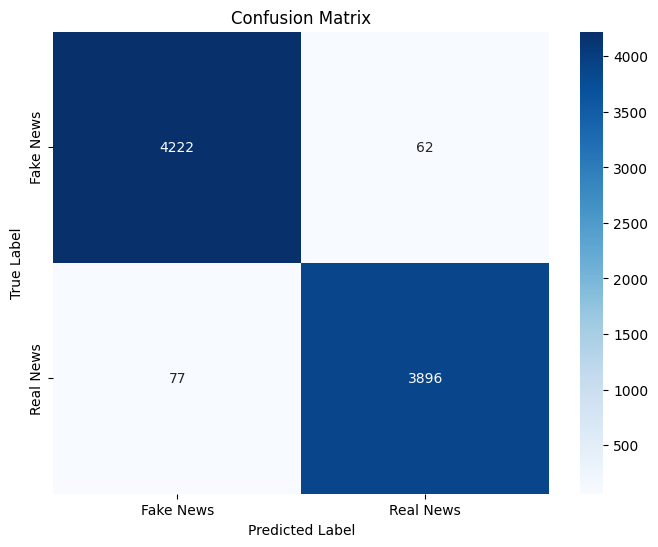


Detailed Metrics:
True Negatives (Correctly identified fake news): 4222
False Positives (Fake news incorrectly classified as real): 62
False Negatives (Real news incorrectly classified as fake): 77
True Positives (Correctly identified real news): 3896

Performance Metrics:
Accuracy: 0.9832
Precision: 0.9843
Recall: 0.9806
F1 Score: 0.9825


In [37]:
# First, import required libraries
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Load the models
loaded_model, loaded_vectorizer = load_models()

# Get predictions using loaded models
predictions = predict_news(test_data['text'], loaded_model, loaded_vectorizer)

# Create confusion matrix
conf_matrix = confusion_matrix(test_data['label'], predictions)

# Print numeric results
print("\nConfusion Matrix:")
print(conf_matrix)

# Calculate and print additional metrics
print("\nClassification Report:")
print(classification_report(test_data['label'], predictions))

# Create a visual confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=['Fake News', 'Real News'],
            yticklabels=['Fake News', 'Real News'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Print detailed metrics
tn, fp, fn, tp = conf_matrix.ravel()
print("\nDetailed Metrics:")
print(f"True Negatives (Correctly identified fake news): {tn}")
print(f"False Positives (Fake news incorrectly classified as real): {fp}")
print(f"False Negatives (Real news incorrectly classified as fake): {fn}")
print(f"True Positives (Correctly identified real news): {tp}")

# Calculate additional performance metrics
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1_score = 2 * (precision * recall) / (precision + recall)

print("\nPerformance Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1_score:.4f}")

In [3]:
import pandas as pd 
df=pd.read_csv(r"C:\Users\HP\Downloads\test.tsv", sep='\t')
test_data = df.drop(df.columns[0], axis=1)

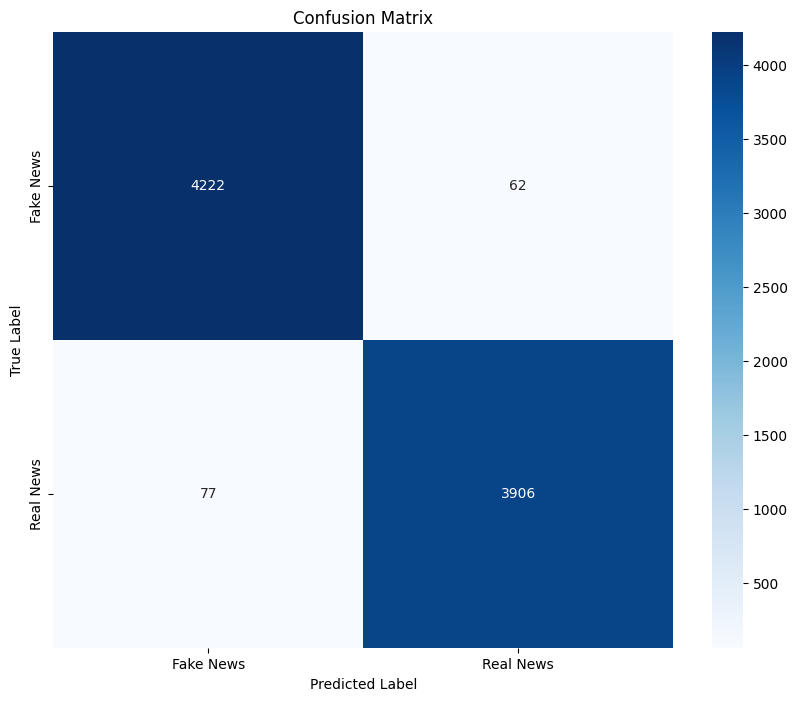


Confusion Matrix:
[[4222   62]
 [  77 3906]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      4284
           1       0.98      0.98      0.98      3983

    accuracy                           0.98      8267
   macro avg       0.98      0.98      0.98      8267
weighted avg       0.98      0.98      0.98      8267


Detailed Results:
True Negatives (Correctly identified fake news): 4222
False Positives (Fake news incorrectly classified as real): 62
False Negatives (Real news incorrectly classified as fake): 77
True Positives (Correctly identified real news): 3906

Accuracy: 0.9832


In [5]:
import pickle
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. First load the models
with open('random_forest_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)
with open('tfidf_vectorizer.pkl', 'rb') as f:
    loaded_vectorizer = pickle.load(f)

# 2. Transform your test data
X_test_vectors = loaded_vectorizer.transform(test_data['text'])

# 3. Make predictions
predictions = loaded_model.predict(X_test_vectors)

# 4. Create and display confusion matrix
conf_matrix = confusion_matrix(test_data['label'], predictions)

# Visual representation
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, 
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Fake News', 'Real News'],
            yticklabels=['Fake News', 'Real News'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 5. Print detailed metrics
print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(classification_report(test_data['label'], predictions))

# 6. Calculate and print individual metrics
tn, fp, fn, tp = conf_matrix.ravel()
print("\nDetailed Results:")
print(f"True Negatives (Correctly identified fake news): {tn}")
print(f"False Positives (Fake news incorrectly classified as real): {fp}")
print(f"False Negatives (Real news incorrectly classified as fake): {fn}")
print(f"True Positives (Correctly identified real news): {tp}")

accuracy = (tp + tn) / (tp + tn + fp + fn)
print(f"\nAccuracy: {accuracy:.4f}")

model evaluation